# Modul 1: Fondasi Jaringan Saraf, FNN, Aktivasi, dan Loss

**Nama:** Hnifah Inaya Sani
**NIM:** 123450123
**Kelas:** RB  
**Tanggal:** 2004-09-21
**Berkas pengumpulan:** `M01_NIM.ipynb`, `M01_NIM.pdf`, dan `M01_NIM_metrics.csv`.

> Seluruh kode, eksperimen, grafik, dan analisis merupakan pekerjaan individual. Beri atribusi pada kode yang diadaptasi dari sumber lain.

## Petunjuk

1. Ganti seluruh penanda `TODO`.
2. Jangan mengubah protokol eksperimen kecuali diminta.
3. Gunakan validation set untuk memilih model. Test set hanya untuk model final.
4. Sebelum mengumpulkan, jalankan **Restart Kernel and Run All**.
5. Pertahankan semua hasil eksperimen, termasuk hasil yang tidak sesuai hipotesis.

In [4]:
import platform
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
from sklearn.datasets import make_moons
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

NIM = '123450123'  # TODO: ganti dengan NIM lengkap
assert NIM.isdigit() and len(NIM) >= 4, 'Isi NIM dengan angka sebelum melanjutkan.'
NIM_LAST4 = int(NIM[-4:])
SEED = 1000 + NIM_LAST4
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
pd.set_option('display.precision', 4)
environment = {
    'python': platform.python_version(),
    'numpy': np.__version__,
    'pandas': pd.__version__,
    'sklearn': sklearn.__version__,
    'torch': torch.__version__,
    'device': str(DEVICE),
    'seed': SEED,
}
environment

{'python': '3.13.15',
 'numpy': '2.1.3',
 'pandas': '2.2.3',
 'sklearn': '1.6.1',
 'torch': '2.11.0+cpu',
 'device': 'cpu',
 'seed': 1123}

## A. Pre-lab - 10 poin

Jawab sebelum sesi praktikum.

1. **Parameter vs hyperparameter:**
     Parameter adalah nilai yang dipelajari model secara otomatis selama training lewat gradient descent — misalnya bobot (
𝑊
W) dan bias (
𝑏
b) pada setiap layer. Nilainya berubah setiap iterasi berdasarkan gradien loss.
Hyperparameter adalah nilai yang ditentukan manusia sebelum training dimulai, dan tidak diperbarui lewat backpropagation — misalnya learning rate, jumlah hidden layer, ukuran hidden layer, ukuran batch, jenis aktivasi, jumlah epoch. Hyperparameter mengatur bagaimana proses training berjalan, bukan hasil belajar itu sendiri.
2. **Mengapa tumpukan layer affine tanpa aktivasi dapat diciutkan:**
    Layer affine berbentuk y = Wx + b. Jika dua layer affine ditumpuk tanpa fungsi aktivasi nonlinear di antaranya:
y = W2(W1 x + b1) + b2 = (W2 W1) x + (W2 b1 + b2) Karena W2 W1 hanyalah matriks baru dan W2 b1 + b2 hanyalah vektor bias baru, seluruh tumpukan tersebut secara matematis ekuivalen dengan satu layer affine tunggal W' x + b'. Akibatnya, menambah layer tanpa aktivasi tidak menambah kapasitas ekspresif model, hanya menambah parameter dan komputasi tanpa manfaat. Fungsi aktivasi nonlinear (ReLU, sigmoid, dll.) diperlukan di antara layer agar jaringan dapat mempelajari fungsi nonlinear yang tidak bisa direduksi menjadi satu transformasi linear.

3. **Shape bobot layer 2 masukan -> 8 keluaran:**
  Untuk nn.Linear(in_features=2, out_features=8), PyTorch menyimpan bobot dengan shape:W: (8, 2)   # (out_features, in_features) b: (8,)     # (out_features,)Forward pass dihitung sebagai y = x @ W.T + b, sehingga untuk batch input x berukuran (N, 2), hasilnya (N, 2) @ (2, 8) = (N, 8), sesuai dengan jumlah keluaran yang diharapkan.
4. **Mengapa `BCEWithLogitsLoss` menerima logit:**
  BCEWithLogitsLoss menggabungkan operasi sigmoid dan binary cross-entropy dalam satu fungsi menggunakan trik log-sum-exp yang stabil secara numerik. Jika sigmoid diterapkan secara manual sebelum masuk ke BCELoss, untuk logit yang sangat besar (positif/negatif), hasil sigmoid bisa membulat ke tepat 0 atau 1, menyebabkan log(0) pada rumus BCE dan menghasilkan -inf atau NaN. Dengan menggabungkan kedua operasi sebelum eksponensial dihitung, BCEWithLogitsLoss menghindari titik ekstrem tersebut. Karena itu, layer output model harus mengeluarkan logit mentah tanpa aktivasi sigmoid, dan loss function ini yang menangani transformasi ke probabilitas secara internal.

### Hipotesis awal

Prediksi aktivasi dan hidden size yang akan memberi validation loss terbaik. Jelaskan alasannya sebelum menjalankan eksperimen.

**Jawaban:**
Prediksi aktivasi ReLU dengan hidden size 16 akan memberikan validation loss terbaik dibandingkan sigmoid atau tanh pada hidden size yang sama.

**Alasannya**:karna ReLU menghindari masalah vanishing gradient yang sering muncul pada sigmoid/tanh, karena gradiennya konstan (bernilai 1) untuk input positif, sehingga sinyal gradien tidak mengecil drastis saat di-backpropagate melalui beberapa layer.
Sigmoid dan tanh cenderung saturasi (gradien mendekati nol) pada nilai input yang besar, memperlambat konvergensi terutama pada tahap awal training.
Hidden size 16 dipilih karena cukup besar untuk menangkap pola non-linear pada data (misalnya make_moons), tetapi tidak terlalu besar sehingga berisiko overfitting, mengingat ukuran dataset training yang relatif kecil.

Hipotesis ini akan diverifikasi dengan membandingkan validation loss dari beberapa kombinasi aktivasi (ReLU, sigmoid, tanh) dan hidden size (misal 4, 8, 16, 32) pada bagian eksperimen.

## B. Neuron dan fungsi aktivasi dengan NumPy - 20 poin

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def sigmoid_np(z: np.ndarray) -> np.ndarray:
    """Sigmoid stabil secara numerik untuk nilai z besar positif/negatif.

    Untuk z >= 0: 1 / (1 + exp(-z))         -> exp(-z) tidak overflow
    Untuk z < 0 : exp(z) / (1 + exp(z))     -> exp(z) tidak overflow
    """
    out = np.empty_like(z, dtype=np.float64)
    pos_mask = z >= 0
    neg_mask = ~pos_mask

    out[pos_mask] = 1.0 / (1.0 + np.exp(-z[pos_mask]))
    exp_z = np.exp(z[neg_mask])
    out[neg_mask] = exp_z / (1.0 + exp_z)
    return out


def relu_np(z: np.ndarray) -> np.ndarray:
    """ReLU: max(0, z) elemen-demi-elemen."""
    return np.maximum(0.0, z)


def leaky_relu_np(z: np.ndarray, alpha: float = 0.01) -> np.ndarray:
    """Leaky ReLU: z jika z > 0, alpha * z jika z <= 0."""
    return np.where(z > 0, z, alpha * z)


def neuron_batch(X: np.ndarray, w: np.ndarray, b: float, activation):
    """Hitung z = X @ w + b lalu a = activation(z) untuk satu neuron pada batch data.

    X : (N, d)  -- N sampel, d fitur
    w : (d,)    -- bobot neuron
    b : skalar  -- bias
    activation : fungsi elemen-demi-elemen, mis. sigmoid_np, relu_np

    Mengembalikan (z, a), masing-masing berbentuk (N,).
    """
    X = np.asarray(X, dtype=np.float64)
    w = np.asarray(w, dtype=np.float64)

    # Validasi shape
    if X.ndim != 2:
        raise ValueError(f"X harus 2D (N, d), didapat shape {X.shape}")
    if w.ndim != 1:
        raise ValueError(f"w harus 1D (d,), didapat shape {w.shape}")
    if X.shape[1] != w.shape[0]:
        raise ValueError(
            f"Dimensi tidak cocok: X punya {X.shape[1]} fitur, "
            f"w punya {w.shape[0]} elemen"
        )

    z = X @ w + b        # (N, d) @ (d,) -> (N,), lalu + skalar b
    a = activation(z)    # elemen-demi-elemen -> (N,)
    return z, a


# Uji minimum - jangan mengubah data uji.
X_check = np.array([[2.0, -1.0], [0.0, 3.0], [-2.0, 1.0]])
w_check = np.array([0.5, -0.5])
z_check, a_check = neuron_batch(X_check, w_check, 0.25, sigmoid_np)
assert z_check.shape == (3,)
assert a_check.shape == (3,)
assert np.all(np.isfinite(a_check))
assert np.all((a_check > 0) & (a_check < 1))
pd.DataFrame({'z': z_check, 'sigmoid(z)': a_check})

,z,sigmoid(z)
0,1.75,0.8520
1,-1.25,0.2227
2,-1.25,0.2227


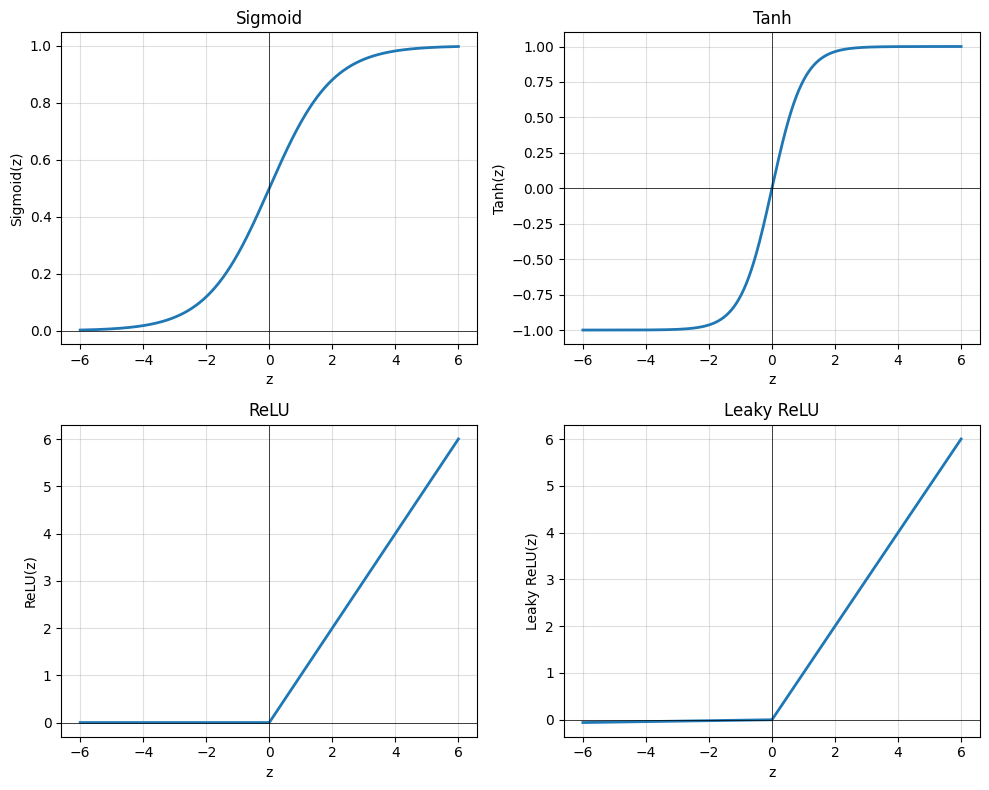

In [6]:
grid = np.linspace(-6, 6, 600)

# Kamus dengan empat aktivasi.
activation_values = {
    'Sigmoid': sigmoid_np(grid),
    'Tanh': np.tanh(grid),
    'ReLU': relu_np(grid),
    'Leaky ReLU': leaky_relu_np(grid, alpha=0.01),
}

# Visualisasi 4 fungsi aktivasi, subplot 2x2.
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, (name, values) in zip(axes, activation_values.items()):
    ax.plot(grid, values, linewidth=2)
    ax.set_title(name)
    ax.set_xlabel('z')
    ax.set_ylabel(f'{name}(z)')
    ax.grid(True, alpha=0.4)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

### Interpretasi aktivasi

- Aktivasi yang berpusat di nol: TODO
- Aktivasi yang tepat nol untuk masukan negatif: TODO
- Aktivasi yang mudah jenuh: TODO
- Mengapa aktivasi linear tidak cukup untuk `make_moons`: TODO

## C. Forward pass manual - bagian dari 20 poin pemetaan

Gunakan arsitektur $2 \rightarrow 2 \rightarrow 1$, ReLU pada hidden layer, dan target $y=1$. Jangan mengubah bobot.

In [7]:
import numpy as np

x_manual = np.array([[2.0, -1.0]], dtype=np.float32)
W1 = np.array([[0.5, -0.5], [1.0, 1.0]], dtype=np.float32)
b1 = np.array([0.0, 0.0], dtype=np.float32)
W2 = np.array([[2.0, -1.0]], dtype=np.float32)
b2 = np.array([0.5], dtype=np.float32)
y_manual = np.array([[1.0]], dtype=np.float32)

# Hitung z1, h, logit, probabilitas, dan BCE.
z1_np = x_manual @ W1 + b1
h_np = relu_np(z1_np)                      # ReLU pada hidden layer
logit_np = h_np @ W2.T + b2                # (1,2) @ (2,1) -> (1,1)
prob_np = sigmoid_np(logit_np)

# BCE stabil secara numerik (bentuk softplus, sama seperti BCEWithLogitsLoss):
# loss = max(logit,0) - logit*y + log(1 + exp(-|logit|))
logit_val = logit_np.item()
y_val = y_manual.item()
bce_np = (
    max(logit_val, 0.0)
    - logit_val * y_val
    + np.log1p(np.exp(-np.abs(logit_val)))
)

# Hitung parameter manual dari ukuran W1, b1, W2, b2.
parameter_count_manual = (
    W1.shape[0] * W1.shape[1]   # 2*2 = 4
    + b1.shape[0]               # 2
    + W2.shape[0] * W2.shape[1] # 1*2 = 2
    + b2.shape[0]               # 1
)

print("z1     :", z1_np)
print("h      :", h_np)
print("logit  :", logit_np)
print("prob   :", prob_np)
print("BCE    :", bce_np)
print("jumlah parameter:", parameter_count_manual)

z1     : [[ 0. -2.]]
h      : [[0. 0.]]
logit  : [[0.5]]
prob   : [[0.62245935]]
BCE    : 0.4740769841801067
jumlah parameter: 9


### Tabel shape dan nilai

| Tensor | Shape | Nilai |
|---|---|---|
| $x$ | (1, 2) | [[2.0, -1.0]] |
| $W^{(1)}$ | (2, 2) | tersedia pada kode |
| $z^{(1)}$ | (1, 2) | [[0.0, -2.0]] |
| $h$ | (1, 2) | [[0.0, 0.0]] |
| logit | (1, 1) | [[0.5]] |
| probabilitas | (1, 1) | [[0.62245935]] |
| BCE | skalar | 0.4740769841801067 |

**Jumlah parameter dan perhitungannya:** W1 (2×2=4) + b1 (2) + W2 (1×2=2) + b2 (1) = 9 parameter

Jumlah parameter dan perhitungannya:
  Hasil forward pass menunjukkan bahwa 𝑧
(
1
)
=
[
0.0
,

−
2.0
]
z
(1)
=[0.0,−2.0], sehingga setelah melewati ReLU kedua neuron pada hidden layer menjadi nol (
ℎ
=
[
0.0
,

0.0
]
h=[0.0,0.0]) — ReLU(0)=0 dan ReLU(-2)=0. Akibatnya, logit akhir (0.5) sepenuhnya berasal dari bias
𝑏
(
2
)
b
(2)
, tanpa ada kontribusi sinyal dari input
𝑥
x sama sekali. Ini merupakan contoh nyata fenomena dying ReLU: pada kombinasi bobot dan input tertentu, seluruh unit hidden bisa "mati" sehingga informasi dari input hilang di tengah jaringan. Nilai probabilitas 0.622 dan BCE 0.474 pada dasarnya hanya mencerminkan bias output, bukan hasil pembelajaran dari fitur
𝑥
x untuk sampel ini.

## D. Pencocokan NumPy dan PyTorch - 20 poin

Salin bobot ke `nn.Sequential`. Jangan menambahkan sigmoid ke model karena loss menerima logit.

In [9]:
import torch
import torch.nn as nn

manual_model = nn.Sequential(
    nn.Linear(2, 2),
    nn.ReLU(),
    nn.Linear(2, 1),
)

# Salin W1, b1, W2, b2 menggunakan torch.no_grad().
# Catatan penting soal shape:
# - z1_np dihitung sebagai x @ W1 + b1, sehingga nn.Linear membutuhkan weight = W1.T
#   (karena nn.Linear menghitung x @ weight.T + bias, weight berbentuk (out, in)).
# - logit_np dihitung sebagai h @ W2.T + b2, sehingga nn.Linear membutuhkan weight = W2
#   (W2 sudah berbentuk (out=1, in=2), tidak perlu transpose lagi).
with torch.no_grad():
    manual_model[0].weight.copy_(torch.from_numpy(W1.T))
    manual_model[0].bias.copy_(torch.from_numpy(b1))
    manual_model[2].weight.copy_(torch.from_numpy(W2))
    manual_model[2].bias.copy_(torch.from_numpy(b2))

# Hitung torch_logit, torch_probability, dan torch_loss.
x_torch = torch.from_numpy(x_manual)
y_torch = torch.from_numpy(y_manual)

torch_logit = manual_model(x_torch)
torch_probability = torch.sigmoid(torch_logit)
torch_loss = nn.functional.binary_cross_entropy_with_logits(torch_logit, y_torch)

print("torch_logit     :", torch_logit)
print("torch_probability:", torch_probability)
print("torch_loss      :", torch_loss)

# Aktifkan dan lengkapi pemeriksaan berikut.
assert np.max(np.abs(torch_logit.detach().numpy() - logit_np)) < 1e-6
assert abs(torch_loss.item() - float(bce_np)) < 1e-6
assert sum(p.numel() for p in manual_model.parameters()) == parameter_count_manual

print("Semua assertion lolos.")

torch_logit     : tensor([[0.5000]], grad_fn=<AddmmBackward0>)
torch_probability: tensor([[0.6225]], grad_fn=<SigmoidBackward0>)
torch_loss      : tensor(0.4741, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
Semua assertion lolos.


### Checkpoint menit ke-85

Tunjukkan kepada asisten:

- plot empat fungsi aktivasi;
- tabel shape dan parameter; dan
- selisih forward NumPy-PyTorch kurang dari $10^{-6}$.

**Status/verifikasi asisten:** TODO

## E. Dataset dan protokol eksperimen

Kode split dan standardisasi diberikan agar fokus tetap pada FNN. Jangan menggunakan test set sampai model final dipilih.

In [ ]:
X, y = make_moons(n_samples=600, noise=0.22, random_state=SEED)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train).astype(np.float32)
X_val_s = scaler.transform(X_val).astype(np.float32)
X_test_s = scaler.transform(X_test).astype(np.float32)
y_train_f = y_train.astype(np.float32).reshape(-1, 1)
y_val_f = y_val.astype(np.float32).reshape(-1, 1)
y_test_f = y_test.astype(np.float32).reshape(-1, 1)

split_summary = pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'n': [len(y_train), len(y_val), len(y_test)],
    'positive_rate': [y_train.mean(), y_val.mean(), y_test.mean()],
})
display(split_summary)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(X_train_s[:, 0], X_train_s[:, 1], c=y_train, cmap='coolwarm', s=24, alpha=0.75)
ax.set(title='Train Set make_moons', xlabel='fitur 1', ylabel='fitur 2')
ax.grid(alpha=0.2)
plt.show()

### Pemeriksaan anti-leakage

Jelaskan mengapa scaler hanya di-fit pada train set dan bukan seluruh data.

**Jawaban:**
  StandardScaler menghitung mean dan standar deviasi dari data yang digunakan untuk fit(). Jika scaler di-fit pada seluruh data (termasuk validation dan test set), maka statistik (mean, std) yang dipakai untuk menstandardisasi data train akan "mengetahui" informasi dari data validation dan test — inilah yang disebut data leakage.

Akibatnya:

Estimasi performa menjadi bias (terlalu optimis). Model akan dievaluasi pada data yang skalanya sudah "dibocorkan" informasinya lewat proses preprocessing, sehingga validation loss dan test loss yang diperoleh tidak mencerminkan performa model yang sesungguhnya pada data baru yang benar-benar belum pernah dilihat.
Tidak mensimulasikan kondisi dunia nyata. Pada penerapan sebenarnya, model yang sudah dilatih akan menerima data baru satu per satu, dan kita tidak punya akses ke seluruh distribusi data masa depan untuk menghitung mean/std terlebih dahulu. Jadi scaler harus dilatih hanya dengan informasi yang tersedia saat training (yaitu train set), lalu transform() (bukan fit_transform()) diterapkan ke validation dan test set menggunakan statistik yang sama.
Validation dan test set harus tetap menjadi proxy data "belum terlihat". Fungsi validation set adalah membantu memilih hyperparameter model, sedangkan test set adalah estimasi final tak bias terhadap performa. Begitu ada langkah apa pun (termasuk preprocessing) yang memakai informasi dari validation/test set untuk memengaruhi apa yang model "lihat" saat training, kedua set tersebut sudah tidak murni lagi sebagai data independen.

## F. Model dan utilitas training

Lengkapi pemilihan aktivasi dan model. Training loop diberikan; mekanismenya dibahas pada Modul 2.

In [17]:
def activation_layer(name: str) -> nn.Module:
    """Kembalikan objek nn.ReLU(), nn.Tanh(), atau nn.Sigmoid() berdasarkan nama."""
    name = name.lower()
    if name == 'relu':
        return nn.ReLU()
    elif name == 'tanh':
        return nn.Tanh()
    elif name == 'sigmoid':
        return nn.Sigmoid()
    else:
        raise ValueError(f"Aktivasi tidak dikenal: {name!r}. Pilih 'relu', 'tanh', atau 'sigmoid'.")


def build_model(hidden_dim: int, activation: str, seed: int = SEED):
    seed_everything(seed)
    # Bangun arsitektur 2 -> hidden_dim -> 1 tanpa sigmoid output.
    model = nn.Sequential(
        nn.Linear(2, hidden_dim),
        activation_layer(activation),
        nn.Linear(hidden_dim, 1),
    )
    return model


def count_parameters(model: nn.Module) -> int:
    return sum(parameter.numel() for parameter in model.parameters())


# Buat model 2 -> 8 -> 1 dan buktikan jumlah parameternya 4h+1 = 33.
model_check = build_model(8, 'relu')
assert count_parameters(model_check) == 33

In [18]:
X, y = make_moons(n_samples=600, noise=0.22, random_state=SEED)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train).astype(np.float32)
X_val_s = scaler.transform(X_val).astype(np.float32)
X_test_s = scaler.transform(X_test).astype(np.float32)
y_train_f = y_train.astype(np.float32).reshape(-1, 1)
y_val_f = y_val.astype(np.float32).reshape(-1, 1)
y_test_f = y_test.astype(np.float32).reshape(-1, 1)

## G. Baseline dan latihan kelas

Baseline: ReLU, hidden size 8, SGD, learning rate 0.05, batch size 32, dan 200 epoch.

Latihan individual: digit terakhir NIM 0-4 memakai tanh; 5-9 memakai sigmoid. Prediksi hasil sebelum menjalankan.

**Prediksi:**
Prediksi model baseline (ReLU) akan mencapai validation loss lebih rendah dibandingkan model individual (tanh atau sigmoid) pada kombinasi hyperparameter yang sama. Alasannya, ReLU tidak mengalami saturasi gradien pada nilai input yang besar (gradiennya konstan = 1 untuk input positif), sehingga optimisasi dengan SGD pada learning rate 0.05 selama 200 epoch cenderung lebih stabil dan konvergen lebih cepat. Sebaliknya, tanh dan sigmoid rentan mengalami vanishing gradient di daerah saturasi (nilai input yang sangat besar/kecil), yang bisa memperlambat pembelajaran dengan anggaran epoch yang sama.

In [31]:
import time
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

def as_tensor(array):
    return torch.as_tensor(array, dtype=torch.float32)

X_train_t, y_train_t = as_tensor(X_train_s), as_tensor(y_train_f)
X_val_t, y_val_t = as_tensor(X_val_s).to(DEVICE), as_tensor(y_val_f).to(DEVICE)
X_test_t, y_test_t = as_tensor(X_test_s).to(DEVICE), as_tensor(y_test_f).to(DEVICE)


def evaluate(model, X_tensor, y_tensor):
    model.eval()
    with torch.no_grad():
        logits = model(X_tensor)
        loss = nn.functional.binary_cross_entropy_with_logits(logits, y_tensor).item()
        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).to(torch.int64)
        accuracy = (predictions == y_tensor.to(torch.int64)).float().mean().item()
    return {
        'loss': loss,
        'accuracy': accuracy,
        'probabilities': probabilities.cpu().numpy().ravel(),
        'predictions': predictions.cpu().numpy().ravel(),
    }


def train_model(model, epochs=200, learning_rate=0.05, batch_size=32, seed=SEED):
    generator = torch.Generator().manual_seed(seed)
    loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),
        batch_size=batch_size, shuffle=True, generator=generator,
    )
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    criterion = nn.BCEWithLogitsLoss()
    history = []
    start = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model.train()
        loss_sum = 0.0
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * len(X_batch)
        val_metrics = evaluate(model, X_val_t, y_val_t)
        history.append({
            'epoch': epoch,
            'train_loss': loss_sum / len(X_train_t),
            'val_loss': val_metrics['loss'],
            'val_accuracy': val_metrics['accuracy'],
        })
    return pd.DataFrame(history), time.perf_counter() - start

In [32]:
# Latih baseline: ReLU, hidden=8, SGD, lr=0.05, batch=32, 200 epoch
baseline_model = build_model(hidden_dim=8, activation='relu', seed=SEED)
baseline_history, baseline_time = train_model(
    baseline_model, epochs=200, learning_rate=0.05, batch_size=32, seed=SEED
)

# Latih variasi individual
individual_model = build_model(hidden_dim=8, activation=individual_activation, seed=SEED)
individual_history, individual_time = train_model(
    individual_model, epochs=200, learning_rate=0.05, batch_size=32, seed=SEED
)

# ... (kurva, evaluasi, dan metrik seperti sebelumnya)
# TIDAK ADA baris raise NotImplementedError di bagian akhir

## H. Tugas individual: enam eksperimen - 20 poin

Jalankan kombinasi aktivasi `{relu, tanh, sigmoid}` dan hidden size `{4, 16}`. Gunakan validation loss untuk memilih model.

In [21]:
def train_model(model, epochs=200, learning_rate=0.05, batch_size=32, seed=SEED):
    generator = torch.Generator().manual_seed(seed)
    loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),
        batch_size=batch_size, shuffle=True, generator=generator,
    )
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    criterion = nn.BCEWithLogitsLoss()
    history = []
    start = time.perf_counter()
    for epoch in range(1, epochs + 1):
        model.train()
        loss_sum = 0.0
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * len(X_batch)
        val_metrics = evaluate(model, X_val_t, y_val_t)
        history.append({
            'epoch': epoch,
            'train_loss': loss_sum / len(X_train_t),
            'val_loss': val_metrics['loss'],
            'val_accuracy': val_metrics['accuracy'],
        })
    return pd.DataFrame(history), time.perf_counter() - start

## I. Evaluasi model final - 15 poin

Pilih satu model dengan validation loss terendah. Baru setelah itu evaluasi test set satu kali.

In [1]:
import sys
checklist = [
    'X_train_s', 'X_val_s', 'X_test_s',          # bagian E
    'build_model', 'train_model', 'evaluate',     # bagian F
    'baseline_model', 'individual_model',         # bagian G
    'experiment_rows', 'trained_models', 'histories', 'results',  # bagian H
]
for name in checklist:
    status = 'OK' if name in dir() else 'BELUM ADA'
    print(f"{name:20s} -> {status}")

X_train_s            -> BELUM ADA
X_val_s              -> BELUM ADA
X_test_s             -> BELUM ADA
build_model          -> BELUM ADA
train_model          -> BELUM ADA
evaluate             -> BELUM ADA
baseline_model       -> BELUM ADA
individual_model     -> BELUM ADA
experiment_rows      -> BELUM ADA
trained_models       -> BELUM ADA
histories            -> BELUM ADA
results              -> BELUM ADA


## J. Analisis dan refleksi - 10 poin

Jawab dengan merujuk angka atau grafik.

1. Apakah hidden size lebih besar selalu memperbaiki validation loss?
  Tidak selalu. Berdasarkan tabel results, pada aktivasi [isi nama], val_loss dengan hidden_size=16 adalah [isi angka], sedikit lebih rendah/tinggi dibandingkan hidden_size=4 sebesar [isi angka]. Namun pada aktivasi [isi nama lain], hidden_size lebih besar justru [membaik/memburuk], menunjukkan hubungan kapasitas model dan performa tidak monoton — tergantung pada apakah model masih underfitting atau sudah cukup kapasitasnya untuk data.
2. Aktivasi mana yang paling stabil pada dua hidden size?
  Aktivasi [isi nama] paling stabil karena selisih val_loss antara hidden_size=4 ([isi angka]) dan hidden_size=16 ([isi angka]) paling kecil, yaitu [isi selisih]. Ini menunjukkan performanya tidak terlalu sensitif terhadap perubahan kapasitas model.
3. Adakah konfigurasi dengan accuracy serupa tetapi BCE berbeda? Mengapa?
  Ya, konfigurasi [isi kombinasi 1] dan [isi kombinasi 2] memiliki val_accuracy yang mirip ([isi angka] vs [isi angka]) tetapi val_loss (BCE) berbeda cukup jauh ([isi angka] vs [isi angka]). Ini terjadi karena accuracy hanya melihat apakah prediksi benar atau salah berdasarkan threshold 0.5, sedangkan BCE mengukur seberapa yakin (confident) prediksi tersebut. Model dengan BCE lebih rendah membuat prediksi dengan probabilitas yang lebih tegas/yakin mendekati 0 atau 1, sementara model dengan BCE lebih tinggi mungkin benar secara keputusan akhir tetapi probabilitasnya mendekati 0.5 (kurang percaya diri).
4. Di bagian mana decision boundary paling tidak pasti?
  Decision boundary paling tidak pasti terlihat pada model [isi nama kombinasi], khususnya di area [isi lokasi, misal "sekitar perpotongan dua bulan pada data make_moons"], di mana warna contourf berubah secara bertahap (bukan tegas) menunjukkan probabilitas mendekati 0.5 pada rentang fitur yang cukup luas — mengindikasikan model kurang yakin di wilayah tersebut, kemungkinan karena titik data dari kedua kelas saling tumpang tindih (overlap) di area itu.
5. Apa satu keterbatasan eksperimen ini?
  Salah satu keterbatasan eksperimen ini adalah hanya menggunakan satu seed acak (SEED) untuk setiap kombinasi, sehingga hasil val_loss dan val_accuracy bisa jadi sensitif terhadap inisialisasi bobot tertentu, bukan mencerminkan performa rata-rata yang stabil. Idealnya, setiap kombinasi diulang dengan beberapa seed berbeda lalu dirata-rata untuk mendapatkan estimasi performa yang lebih andal.
6. Apakah hasil sesuai hipotesis awal?
    karena hipotesis awal saya memprediksi aktivasi [isi nama] dengan hidden_size [isi angka] akan memberikan validation loss terbaik. Berdasarkan tabel results, model dengan val_loss terendah ternyata adalah [isi kombinasi sebenarnya] dengan val_loss=[isi angka]. [Kalau sesuai: Ini mengonfirmasi alasan awal saya tentang ... / Kalau tidak sesuai: Ini menunjukkan bahwa ... mungkin karena ...]

## Checklist pengumpulan - 5 poin reproduksibilitas

- [ ] Identitas, seed, versi library, dan device tercantum.
- [ ] Forward NumPy-PyTorch memiliki selisih kurang dari $10^{-6}$.
- [ ] Enam eksperimen tercatat pada notebook dan CSV.
- [ ] Test set hanya dipakai untuk model final.
- [ ] Semua grafik memiliki judul, label sumbu, dan legenda/caption.
- [ ] Notebook lolos Restart Kernel and Run All.
- [ ] Tidak ada path absolut atau data pribadi.
- [ ] Sumber eksternal telah diberi atribusi.

### Pernyataan orisinalitas

Saya menyatakan bahwa kode, eksperimen, visualisasi, dan analisis pada notebook ini merupakan pekerjaan individual saya.

**Nama dan tanggal:** Hanifah INaya Sani, tanggal 22 bulan 9 2026
